In [ ]:
# Importar librerías
import pandas as pd

#Paso 1
# Cargar datos consolidados 
df = pd.read_csv("datos_consolidados.csv")
# df = pd.read_excel("datos_consolidados.csv")

# Ver las primeras filas
df.head()


,manufacturer,brand,item,item_description,category,format_x,attr1_x,attr2_x,attr3_x,id_category,attr1_y,attr2_y,attr3_y,format_y,segment,full_description,segment_count
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,NaN,CLORO,CLORO,BAMBINO,LIQUIDO,BLEACH,CLORALEX - CLORALEX EL RENDIDOR BOT.PLAST. 250...,7070
1,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,NaN,CLORO,CLORO,GERMICIDA,LIQUIDO,BLEACH,CLORALEX - CLORALEX EL RENDIDOR BOT.PLAST. 250...,7070
2,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,NaN,CLORO,CLORO,MASCOTAS,LIQUIDO,BLEACH,CLORALEX - CLORALEX EL RENDIDOR BOT.PLAST. 250...,7070
3,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,NaN,CLORO,CLORO,MULTIUSOS,GEL,BLEACH,CLORALEX - CLORALEX EL RENDIDOR BOT.PLAST. 250...,7070
4,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,NaN,CLORO,CLORO,MULTIUSOS,LIQUIDO,BLEACH,CLORALEX - CLORALEX EL RENDIDOR BOT.PLAST. 250...,7070


In [ ]:
# Información general de las columnas
df.info()

# Resumen estadístico de las variables numéricas
df.describe()

# Columnas disponibles
print(df.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26765 entries, 0 to 26764
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   manufacturer      26765 non-null  object 
 1   brand             26765 non-null  object 
 2   item              26765 non-null  object 
 3   item_description  26765 non-null  object 
 4   category          26765 non-null  int64  
 5   format_x          26765 non-null  object 
 6   attr1_x           26447 non-null  object 
 7   attr2_x           26765 non-null  object 
 8   attr3_x           26447 non-null  object 
 9   id_category       0 non-null      float64
 10  attr1_y           26765 non-null  object 
 11  attr2_y           26765 non-null  object 
 12  attr3_y           26260 non-null  object 
 13  format_y          26765 non-null  object 
 14  segment           26765 non-null  object 
 15  full_description  26765 non-null  object 
 16  segment_count     26765 non-null  int64 

### Paso 2: Identificación de variables clave

Para realizar el análisis exploratorio de ventas, se identifican las siguientes variables relevantes en la tabla consolidada:

- **Variables de ventas (cuantitativas):**
  - `TOTAL_UNIT_SALES`: cantidad total de unidades vendidas.
  - `TOTAL_VALUE_SALES`: valor total de ventas en moneda.
  - `TOTAL_UNIT_AVG_WEEKLY_SALES`: promedio de ventas semanales.

- **Variables temporales:**
  - `DATE`: fecha exacta de la venta.
  - `WEEK`, `YEAR`, `MONTH`: permiten analizar tendencias a lo largo del tiempo.

- **Variables categóricas:**
  - `CATEGORY`: categoría del producto (ej. AIR CARE, LAVAVAJILLAS).
  - `BRAND`: marca (ej. CLORALEX).
  - `SEGMENT`: segmento de producto (ej. BLEACH).
  - `REGION`: región geográfica de la venta.
  - `FORMAT`: presentación del producto (ej. líquido, gel).

Estas variables son relevantes porque nos permitirán responder preguntas de negocio como:
- ¿Qué categorías y marcas generan mayores ventas?
- ¿Cómo se comportan las ventas a lo largo del tiempo?
- ¿Qué regiones aportan más al total de ventas?
- ¿Existen outliers o anomalías en las ventas por producto/categoría?


In [4]:
# Revisar columnas disponibles
print(df.columns)

# Ver valores únicos en variables categóricas principales
for col in ['CATEGORY', 'BRAND', 'SEGMENT', 'REGION', 'FORMAT']:
    if col in df.columns:
        print(f"\n{col} ({df[col].nunique()} valores únicos):")
        print(df[col].unique()[:5])  # muestra los primeros 5 únicos


Index(['manufacturer', 'brand', 'item', 'item_description', 'category',
       'format_x', 'attr1_x', 'attr2_x', 'attr3_x', 'id_category', 'attr1_y',
       'attr2_y', 'attr3_y', 'format_y', 'segment', 'full_description',
       'segment_count'],
      dtype='object')


### Paso 3: Visualización de la distribución de ventas

Para analizar la distribución de las ventas se utilizaron dos enfoques:

- **Histogramas:** muestran cómo se distribuyen las ventas en diferentes rangos de valores.  
- **Boxplots:** permiten identificar la mediana, la dispersión y posibles outliers en las ventas por categoría.

Las variables de interés son:
- `TOTAL_VALUE_SALES`: valor total de ventas.  
- `CATEGORY`: categorías de productos.  


In [9]:
import pandas as pd

# 1. Cargar las tablas base
df_product = pd.read_csv("DIM_PRODUCT.csv")   # o .xlsx
df_category = pd.read_csv("DIM_CATEGORY.csv")
df_segment = pd.read_csv("DIM_SEGMENT.csv")
fact_sales = pd.read_csv("FACT_SALES.csv")
calendar = pd.read_csv("DIM_CALENDAR.csv")

# 2. Normalizar columnas para evitar espacios y tipos distintos
for df_temp in [df_product, df_category, df_segment]:
    df_temp.columns = df_temp.columns.str.strip()
    for col in df_temp.select_dtypes(include="object").columns:
        df_temp[col] = df_temp[col].astype(str).str.strip()

# 3. Crear df_product_full (producto + categoría + segmento)
df_product_full = df_product.merge(
    df_category.rename(columns={"ID_CATEGORY":"id_category", "CATEGORY":"category"}),
    left_on="CATEGORY", right_on="id_category", how="left"
)
df_product_full = df_product_full.merge(
    df_segment, left_on="CATEGORY", right_on="CATEGORY", how="left"
)

# 4. Merge producto con ventas
df_ventas = fact_sales.merge(df_product_full, left_on="ITEM_CODE", right_on="ITEM", how="left")

# 5. Merge con calendario (para tener fechas)
df_ventas = df_ventas.merge(calendar[['WEEK','DATE','YEAR','MONTH']], on="WEEK", how="left")

# 6. Revisar columnas finales
print(df_ventas.columns.tolist())
df_ventas.head()



['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION', 'MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY', 'FORMAT_x', 'ATTR1_x', 'ATTR2_x', 'ATTR3_x', 'id_category', 'category', 'ATTR1_y', 'ATTR2_y', 'ATTR3_y', 'FORMAT_y', 'SEGMENT', 'DATE', 'YEAR', 'MONTH']


,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,...,id_category,category,ATTR1_y,ATTR2_y,ATTR3_y,FORMAT_y,SEGMENT,DATE,YEAR,MONTH
0,34-22,7501058792808BP2,0.006,0.139,1.0,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,...,1.0,FABRIC TREATMENT and SANIT,CLORO,CLORO,BAMBINO,LIQUIDO,BLEACH,28/08/2022,2022.0,8.0
1,34-22,7501058792808BP2,0.006,0.139,1.0,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,...,1.0,FABRIC TREATMENT and SANIT,CLORO,CLORO,GERMICIDA,LIQUIDO,BLEACH,28/08/2022,2022.0,8.0
2,34-22,7501058792808BP2,0.006,0.139,1.0,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,...,1.0,FABRIC TREATMENT and SANIT,CLORO,CLORO,MASCOTAS,LIQUIDO,BLEACH,28/08/2022,2022.0,8.0
3,34-22,7501058792808BP2,0.006,0.139,1.0,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,...,1.0,FABRIC TREATMENT and SANIT,CLORO,CLORO,MULTIUSOS,GEL,BLEACH,28/08/2022,2022.0,8.0
4,34-22,7501058792808BP2,0.006,0.139,1.0,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,...,1.0,FABRIC TREATMENT and SANIT,CLORO,CLORO,MULTIUSOS,LIQUIDO,BLEACH,28/08/2022,2022.0,8.0


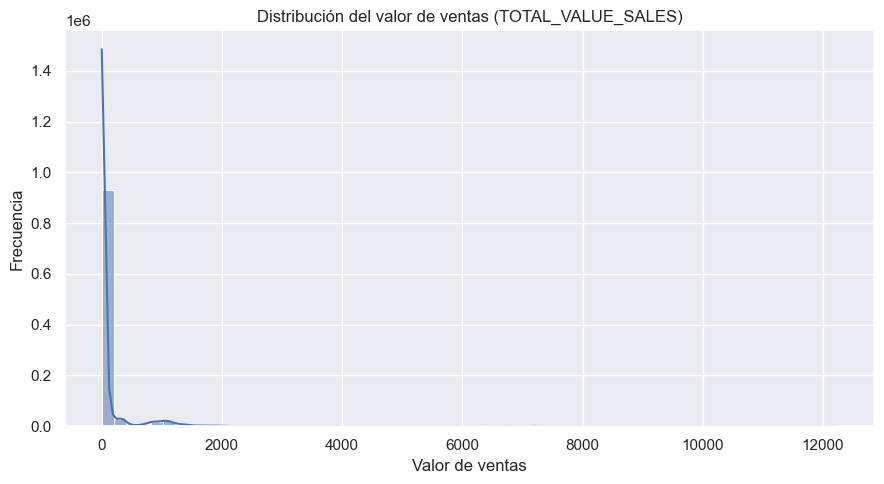

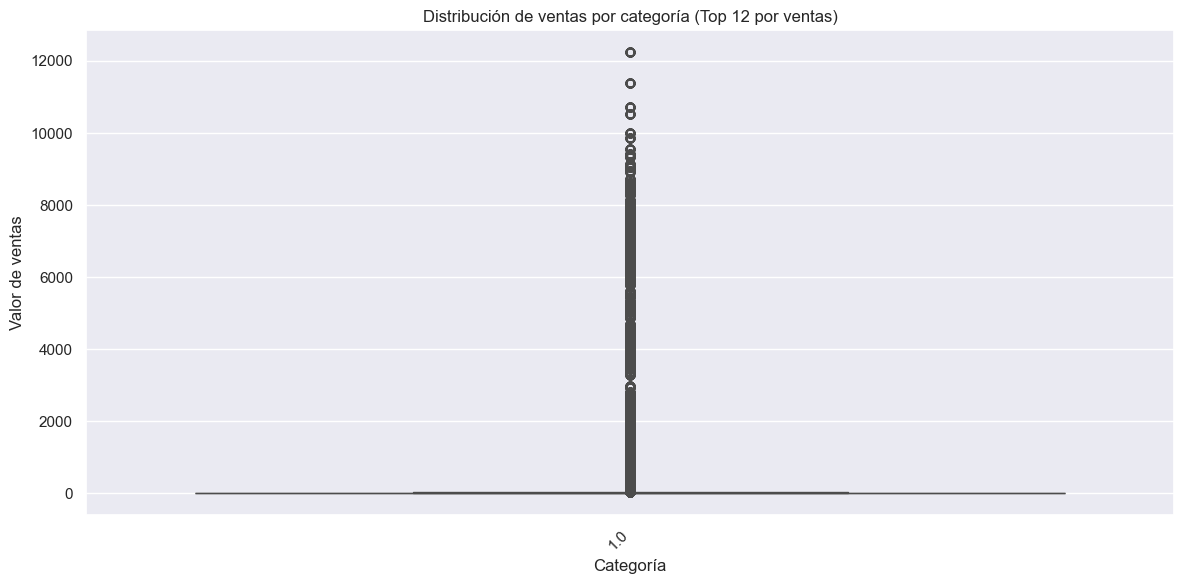

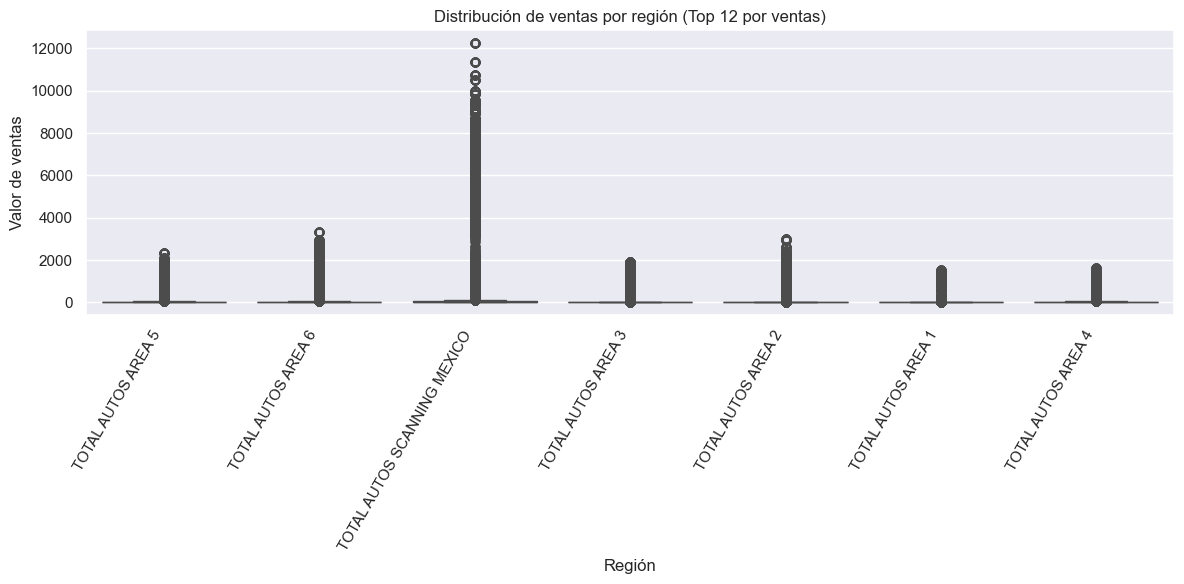

In [12]:
# --- Limpieza mínima antes de graficar ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Convertir ventas en datos numericos
for col in ["TOTAL_VALUE_SALES", "TOTAL_UNIT_SALES", "TOTAL_UNIT_AVG_WEEKLY_SALES"]:
    if col in df_ventas.columns:
        df_ventas[col] = pd.to_numeric(df_ventas[col], errors="coerce")

# --- 3.1 Histograma del valor de ventas ---
plt.figure(figsize=(9,5))
sns.histplot(df_plot["TOTAL_VALUE_SALES"], bins=60, kde=True)
plt.title("Distribución del valor de ventas (TOTAL_VALUE_SALES)")
plt.xlabel("Valor de ventas")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("dist_total_value_sales.png", dpi=120)
plt.show()

# --- 3.2 Boxplot por CATEGORÍA ---
if "CATEGORY" in df_plot.columns:
    top_cat = (df_plot.groupby("CATEGORY")["TOTAL_VALUE_SALES"]
                      .sum()
                      .sort_values(ascending=False)
                      .head(12)              # limita a top 12 para que se lea
                      .index)
    df_cat = df_plot[df_plot["CATEGORY"].isin(top_cat)]

    plt.figure(figsize=(12,6))
    sns.boxplot(data=df_cat, x="CATEGORY", y="TOTAL_VALUE_SALES", showfliers=True)
    plt.title("Distribución de ventas por categoría (Top 12 por ventas)")
    plt.xlabel("Categoría")
    plt.ylabel("Valor de ventas")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("boxplot_categoria.png", dpi=120)
    plt.show()

# --- 3.3 Boxplot por REGIÓN (opcional) ---
if "REGION" in df_plot.columns:
    top_reg = (df_plot.groupby("REGION")["TOTAL_VALUE_SALES"]
                      .sum()
                      .sort_values(ascending=False)
                      .head(12)
                      .index)
    df_reg = df_plot[df_plot["REGION"].isin(top_reg)]

    plt.figure(figsize=(12,6))
    sns.boxplot(data=df_reg, x="REGION", y="TOTAL_VALUE_SALES", showfliers=True)
    plt.title("Distribución de ventas por región (Top 12 por ventas)")
    plt.xlabel("Región")
    plt.ylabel("Valor de ventas")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.savefig("boxplot_region.png", dpi=120)
    plt.show()



### Paso 4: Tendencia de ventas en el tiempo

Para comprender la evolución de las ventas, se utilizaron gráficos de líneas que permiten observar el comportamiento del valor de ventas a lo largo del tiempo.  

Los enfoques aplicados fueron:

- **Tendencia total de ventas:** se graficó la evolución del valor total de ventas en el tiempo para identificar picos, caídas y patrones generales.  
- **Tendencia por categorías:** se analizaron las categorías principales para comparar cómo varían sus ventas en el tiempo.  
- **Tendencia por regiones:** se representó la evolución de las ventas en diferentes regiones, lo que ayuda a detectar cuáles zonas mantienen un mejor desempeño o presentan cambios significativos.  

Las variables de interés en este análisis son:  
- `DATE`: fecha de la venta.  
- `TOTAL_VALUE_SALES`: valor total de ventas.  
- `CATEGORY`: categoría de producto.  
- `REGION`: región geográfica de la venta.  


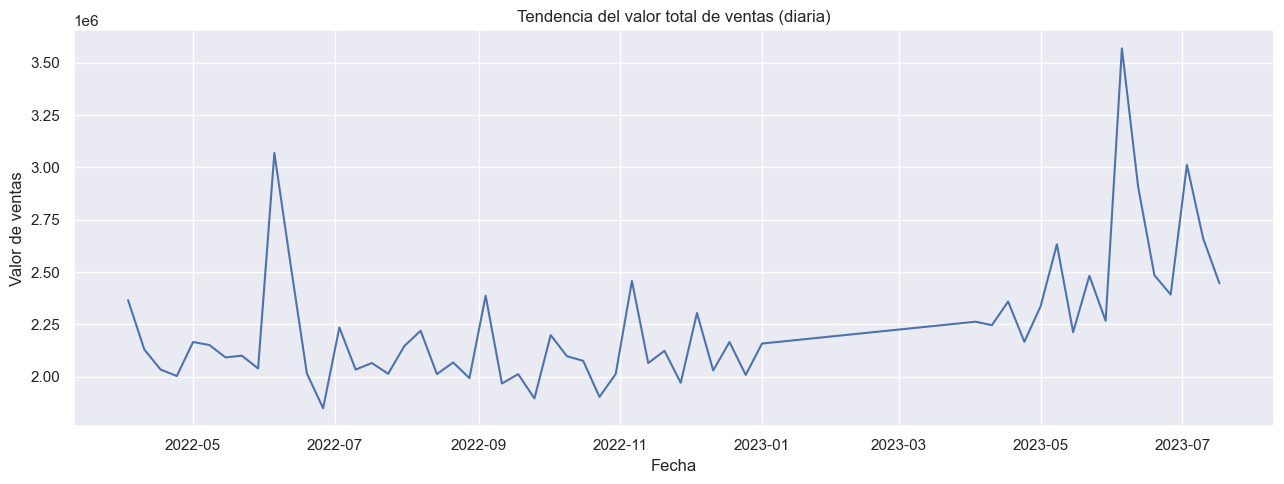

C:\Users\zuzan\AppData\Local\Temp\ipykernel_26564\3784834084.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_mensual = ts_total.resample("M").sum()


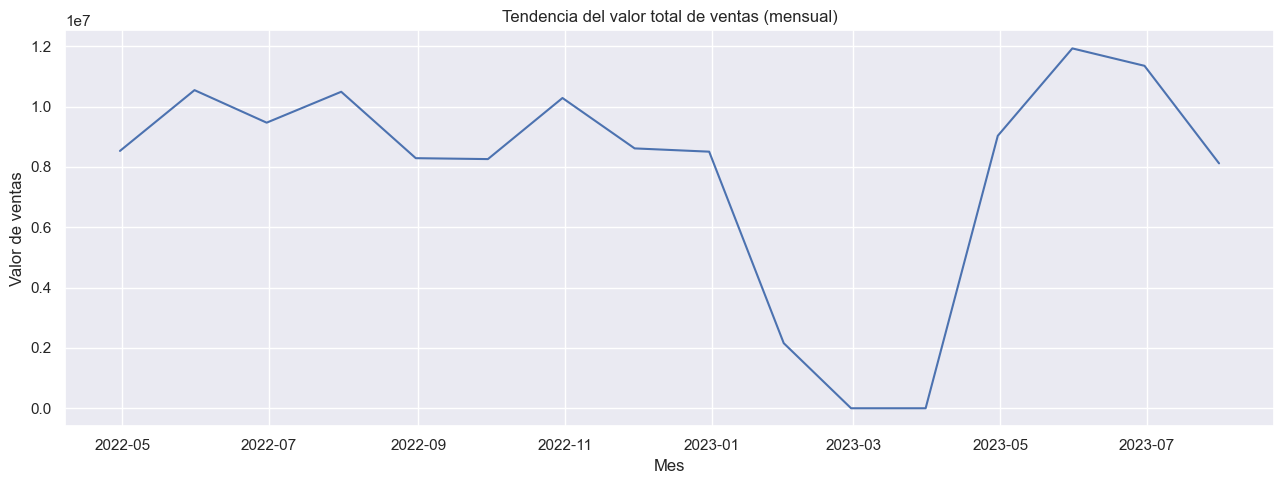

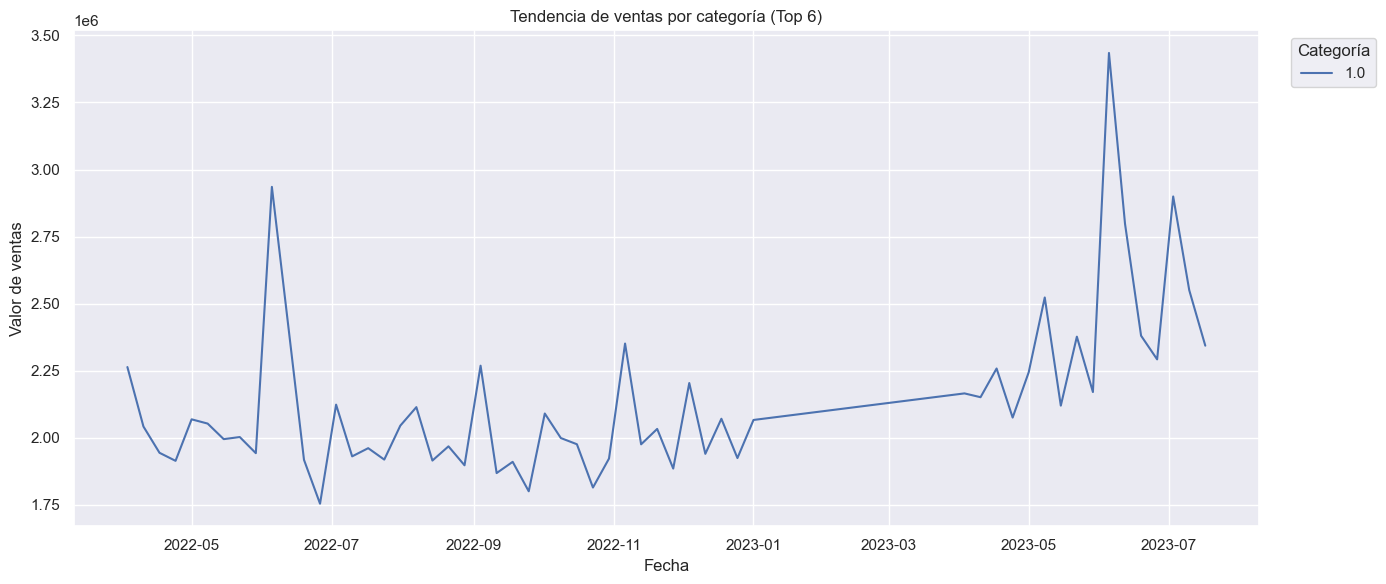

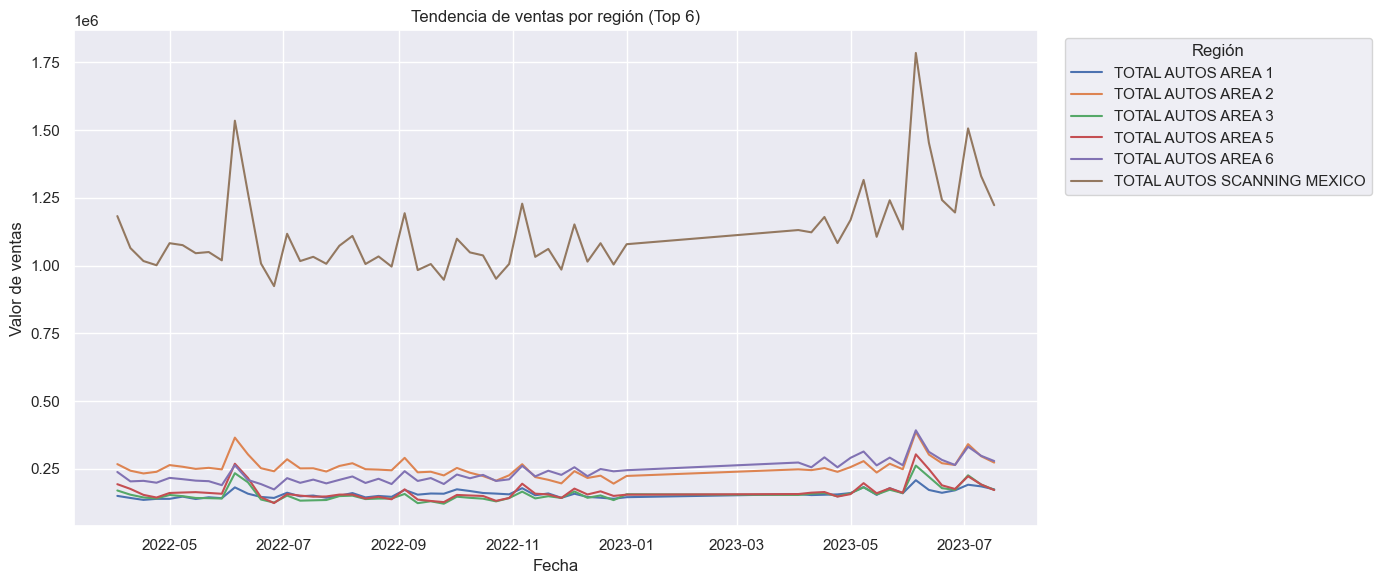

In [14]:
# === PASO 4: Tendencia de ventas en el tiempo ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# 4.0 Fecha y columnas numéricas
df_ventas.columns = df_ventas.columns.str.strip()
df_ventas["DATE"] = pd.to_datetime(df_ventas["DATE"], errors="coerce", dayfirst=True)

for col in ["TOTAL_VALUE_SALES", "TOTAL_UNIT_SALES", "TOTAL_UNIT_AVG_WEEKLY_SALES"]:
    if col in df_ventas.columns:
        df_ventas[col] = pd.to_numeric(df_ventas[col], errors="coerce")

df_time = df_ventas[df_ventas["DATE"].notna()].copy()

# ---- 4.1 Tendencia total diaria ----
ts_total = (df_time
            .groupby("DATE", as_index=True)["TOTAL_VALUE_SALES"]
            .sum()
            .sort_index())

plt.figure(figsize=(13,5))
plt.plot(ts_total.index, ts_total.values)
plt.title("Tendencia del valor total de ventas (diaria)")
plt.xlabel("Fecha")
plt.ylabel("Valor de ventas")
plt.tight_layout()
plt.savefig("tendencia_total_diaria.png", dpi=140)
plt.show()

# ---- 4.2 Tendencia mensual (resample) ----
ts_mensual = ts_total.resample("M").sum()

plt.figure(figsize=(13,5))
plt.plot(ts_mensual.index, ts_mensual.values)
plt.title("Tendencia del valor total de ventas (mensual)")
plt.xlabel("Mes")
plt.ylabel("Valor de ventas")
plt.tight_layout()
plt.savefig("tendencia_total_mensual.png", dpi=140)
plt.show()

# ---- 4.3 Tendencia por CATEGORÍA (Top 6 por ventas totales) ----
if {"CATEGORY", "TOTAL_VALUE_SALES"}.issubset(df_time.columns):
    top_cat = (df_time.groupby("CATEGORY")["TOTAL_VALUE_SALES"]
                     .sum()
                     .sort_values(ascending=False)
                     .head(6)
                     .index)

    df_topcat = df_time[df_time["CATEGORY"].isin(top_cat)].copy()

    ts_cat = (df_topcat
              .groupby(["DATE", "CATEGORY"])["TOTAL_VALUE_SALES"]
              .sum()
              .reset_index())

    plt.figure(figsize=(14,6))
    sns.lineplot(data=ts_cat, x="DATE", y="TOTAL_VALUE_SALES", hue="CATEGORY")
    plt.title("Tendencia de ventas por categoría (Top 6)")
    plt.xlabel("Fecha")
    plt.ylabel("Valor de ventas")
    plt.legend(title="Categoría", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("tendencia_por_categoria.png", dpi=140)
    plt.show()

# ---- 4.4 Tendencia por REGIÓN (Top 6 por ventas totales) ----
if {"REGION", "TOTAL_VALUE_SALES"}.issubset(df_time.columns):
    top_reg = (df_time.groupby("REGION")["TOTAL_VALUE_SALES"]
                     .sum()
                     .sort_values(ascending=False)
                     .head(6)
                     .index)

    df_topreg = df_time[df_time["REGION"].isin(top_reg)].copy()

    ts_reg = (df_topreg
              .groupby(["DATE", "REGION"])["TOTAL_VALUE_SALES"]
              .sum()
              .reset_index())

    plt.figure(figsize=(14,6))
    sns.lineplot(data=ts_reg, x="DATE", y="TOTAL_VALUE_SALES", hue="REGION")
    plt.title("Tendencia de ventas por región (Top 6)")
    plt.xlabel("Fecha")
    plt.ylabel("Valor de ventas")
    plt.legend(title="Región", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("tendencia_por_region.png", dpi=140)
    plt.show()


### Paso 5: Relación entre diferentes variables

Se generaron gráficos de dispersión (scatter plots) para analizar la relación entre variables clave:

- `TOTAL_UNIT_SALES` vs `TOTAL_VALUE_SALES`: permite observar si existe una relación lineal entre el número de unidades vendidas y el valor total de ventas.  
- `TOTAL_UNIT_AVG_WEEKLY_SALES` vs `TOTAL_VALUE_SALES`: muestra si los promedios semanales de ventas se asocian con un mayor valor de ventas.  

Además, se construyó un **mapa de calor de correlación** para todas las variables numéricas, lo que ayuda a identificar correlaciones positivas o negativas entre métricas de ventas.


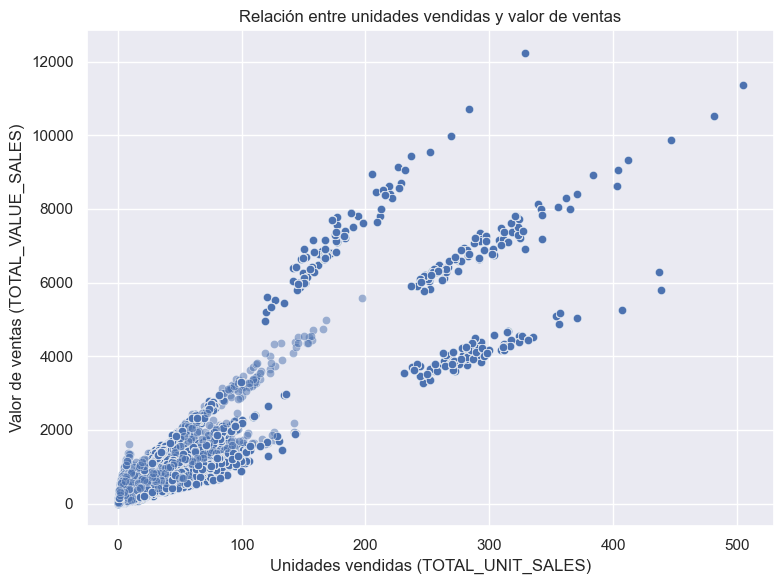

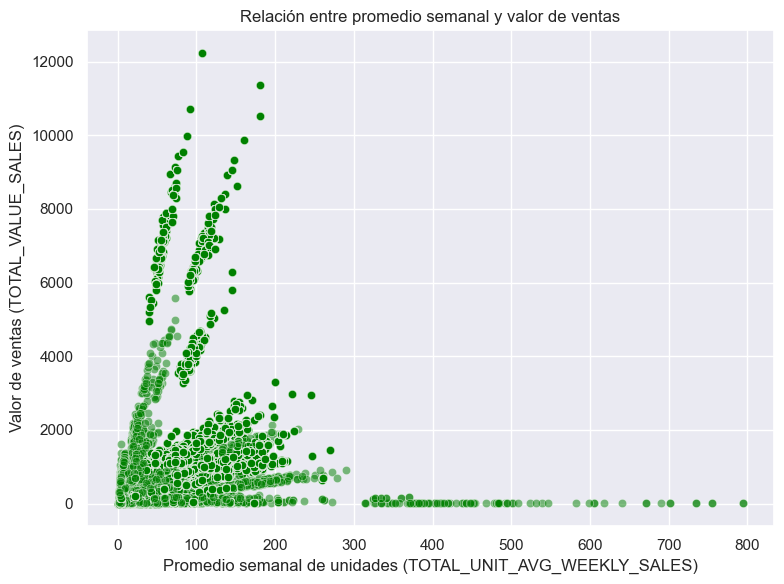

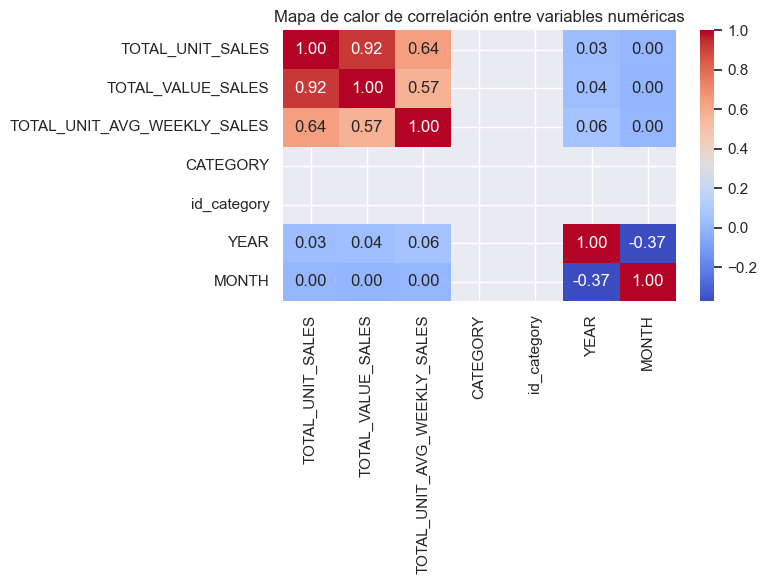

In [16]:
# === PASO 5: Relación entre diferentes variables ===
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Asegurar que las columnas numéricas estén en formato correcto
for col in ["TOTAL_VALUE_SALES", "TOTAL_UNIT_SALES", "TOTAL_UNIT_AVG_WEEKLY_SALES"]:
    if col in df_ventas.columns:
        df_ventas[col] = pd.to_numeric(df_ventas[col], errors="coerce")

# --- 5.1 Scatter: unidades vs valor de ventas ---
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_ventas, x="TOTAL_UNIT_SALES", y="TOTAL_VALUE_SALES", alpha=0.5)
plt.title("Relación entre unidades vendidas y valor de ventas")
plt.xlabel("Unidades vendidas (TOTAL_UNIT_SALES)")
plt.ylabel("Valor de ventas (TOTAL_VALUE_SALES)")
plt.tight_layout()
plt.savefig("scatter_units_vs_value.png", dpi=140)
plt.show()

# --- 5.2 Scatter: promedio semanal vs valor de ventas ---
if "TOTAL_UNIT_AVG_WEEKLY_SALES" in df_ventas.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df_ventas, 
                    x="TOTAL_UNIT_AVG_WEEKLY_SALES", 
                    y="TOTAL_VALUE_SALES", alpha=0.5, color="green")
    plt.title("Relación entre promedio semanal y valor de ventas")
    plt.xlabel("Promedio semanal de unidades (TOTAL_UNIT_AVG_WEEKLY_SALES)")
    plt.ylabel("Valor de ventas (TOTAL_VALUE_SALES)")
    plt.tight_layout()
    plt.savefig("scatter_weekly_vs_value.png", dpi=140)
    plt.show()

# --- 5.3 Heatmap de correlación ---
# Seleccionamos solo columnas numéricas
num_cols = df_ventas.select_dtypes(include="number")

plt.figure(figsize=(8,6))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlación entre variables numéricas")
plt.tight_layout()
plt.savefig("heatmap_correlacion.png", dpi=140)
plt.show()



### Paso 6: Visualización geográfica de las ventas

Para analizar el desempeño de ventas por región se utilizaron gráficos de barras.  
Este análisis permite identificar qué regiones tienen mayor participación en el valor total de ventas.

Las variables de interés son:
- `REGION`: región geográfica de la venta.  
- `TOTAL_VALUE_SALES`: valor total de ventas.  


C:\Users\zuzan\AppData\Local\Temp\ipykernel_26564\1454893362.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_region, x="REGION", y="TOTAL_VALUE_SALES", palette="viridis")


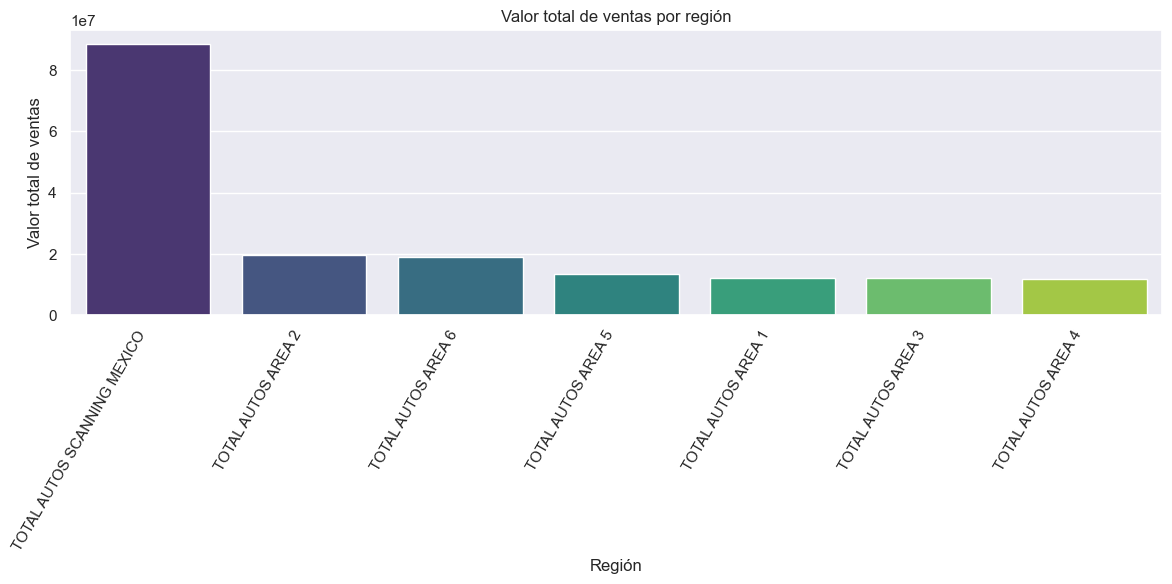

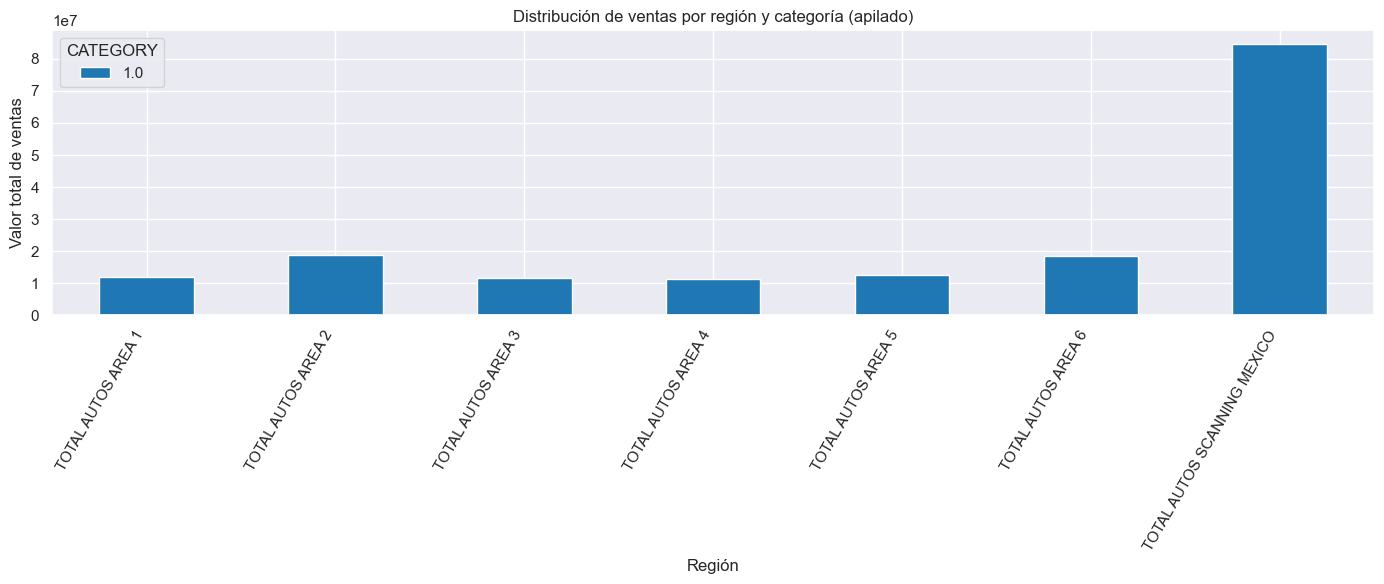

In [17]:
# === PASO 6: Distribución geográfica de ventas ===

# Agrupamos por región
ventas_region = (df_ventas
                 .groupby("REGION")["TOTAL_VALUE_SALES"]
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index())

# --- 6.1 Barra simple: ventas por región ---
plt.figure(figsize=(12,6))
sns.barplot(data=ventas_region, x="REGION", y="TOTAL_VALUE_SALES", palette="viridis")
plt.title("Valor total de ventas por región")
plt.xlabel("Región")
plt.ylabel("Valor total de ventas")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig("ventas_por_region.png", dpi=140)
plt.show()

# --- 6.2 Barra apilada (opcional): categorías por región ---
if {"REGION","CATEGORY"}.issubset(df_ventas.columns):
    ventas_reg_cat = (df_ventas
                      .groupby(["REGION","CATEGORY"])["TOTAL_VALUE_SALES"]
                      .sum()
                      .reset_index())

    pivot_reg_cat = ventas_reg_cat.pivot(index="REGION", columns="CATEGORY", values="TOTAL_VALUE_SALES").fillna(0)

    pivot_reg_cat.plot(kind="bar", stacked=True, figsize=(14,6), colormap="tab20")
    plt.title("Distribución de ventas por región y categoría (apilado)")
    plt.xlabel("Región")
    plt.ylabel("Valor total de ventas")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.savefig("ventas_region_categoria.png", dpi=140)
    plt.show()


### Paso 7: Identificación de outliers y anomalías

Se utilizaron boxplots para detectar valores atípicos en las ventas.  
El análisis de outliers es importante porque permite identificar patrones inusuales, posibles errores de captura o ventas extraordinarias.

Las variables analizadas son:
- `TOTAL_VALUE_SALES`: valor total de ventas.  
- `TOTAL_UNIT_SALES`: unidades vendidas.  

Los boxplots se generaron por:
- Categoría de producto (`CATEGORY`).  
- Región (`REGION`).  


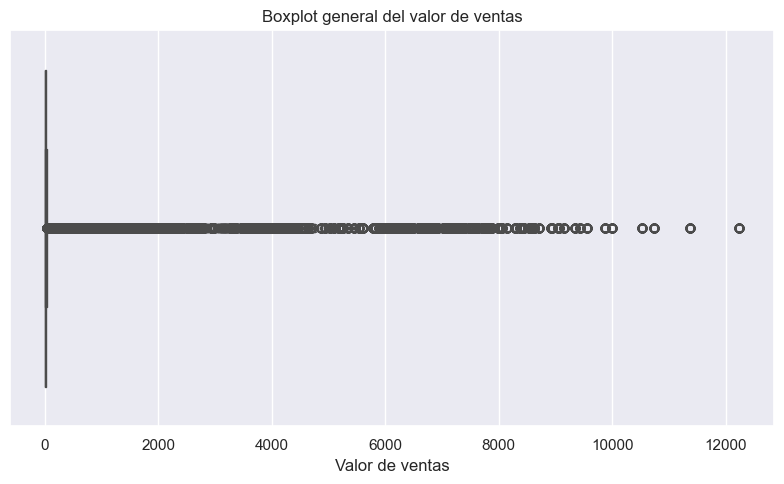

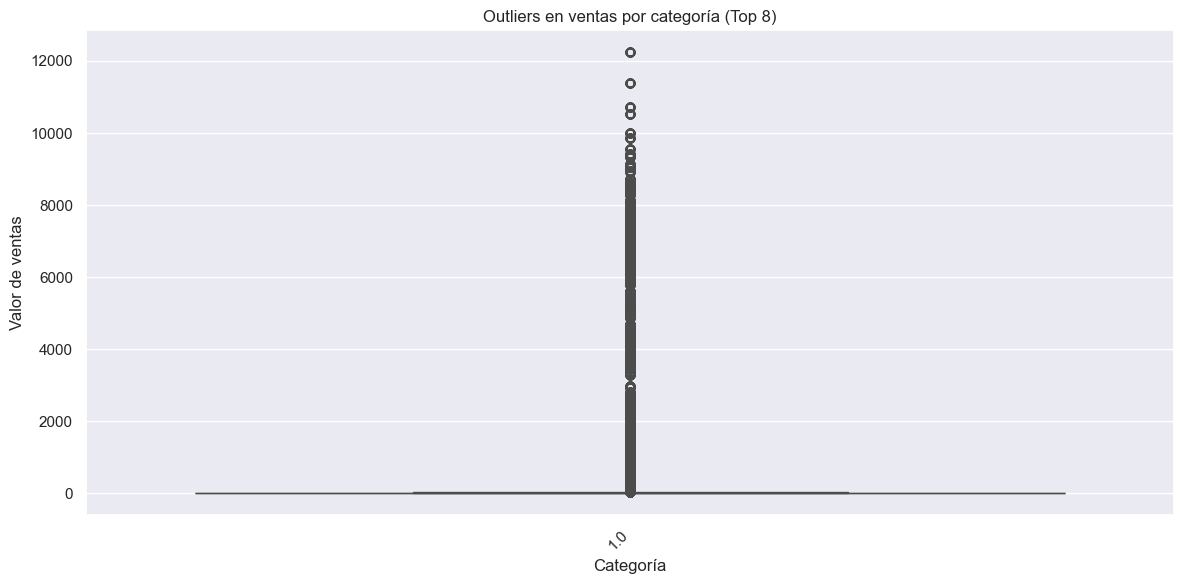

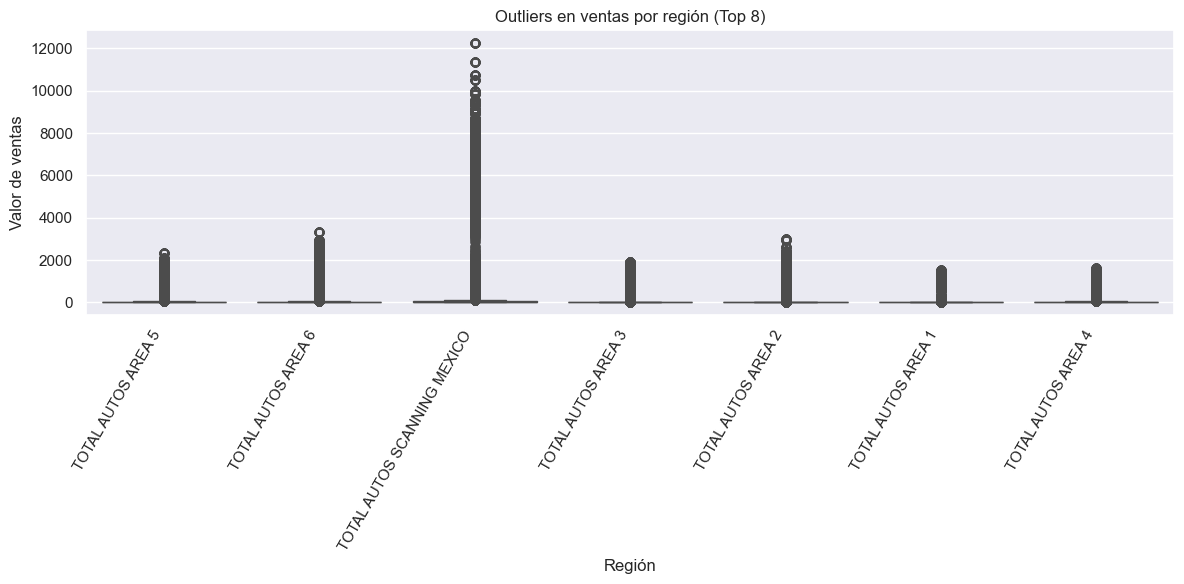

In [18]:
# === PASO 7: Outliers y anomalías ===

# --- 7.1 Boxplot simple de TOTAL_VALUE_SALES ---
plt.figure(figsize=(8,5))
sns.boxplot(x=df_ventas["TOTAL_VALUE_SALES"])
plt.title("Boxplot general del valor de ventas")
plt.xlabel("Valor de ventas")
plt.tight_layout()
plt.savefig("boxplot_total_value.png", dpi=140)
plt.show()

# --- 7.2 Boxplot por categoría ---
if {"CATEGORY","TOTAL_VALUE_SALES"}.issubset(df_ventas.columns):
    top_cat = (df_ventas.groupby("CATEGORY")["TOTAL_VALUE_SALES"]
                        .sum()
                        .sort_values(ascending=False)
                        .head(8)  # limitar a top 8 para mejor legibilidad
                        .index)
    df_topcat = df_ventas[df_ventas["CATEGORY"].isin(top_cat)]

    plt.figure(figsize=(12,6))
    sns.boxplot(data=df_topcat, x="CATEGORY", y="TOTAL_VALUE_SALES")
    plt.title("Outliers en ventas por categoría (Top 8)")
    plt.xlabel("Categoría")
    plt.ylabel("Valor de ventas")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("boxplot_outliers_categoria.png", dpi=140)
    plt.show()

# --- 7.3 Boxplot por región ---
if {"REGION","TOTAL_VALUE_SALES"}.issubset(df_ventas.columns):
    top_reg = (df_ventas.groupby("REGION")["TOTAL_VALUE_SALES"]
                        .sum()
                        .sort_values(ascending=False)
                        .head(8)
                        .index)
    df_topreg = df_ventas[df_ventas["REGION"].isin(top_reg)]

    plt.figure(figsize=(12,6))
    sns.boxplot(data=df_topreg, x="REGION", y="TOTAL_VALUE_SALES")
    plt.title("Outliers en ventas por región (Top 8)")
    plt.xlabel("Región")
    plt.ylabel("Valor de ventas")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.savefig("boxplot_outliers_region.png", dpi=140)
    plt.show()


### Paso 8: Documentar insights y guardar visualizaciones

En este paso se presentan los principales hallazgos obtenidos en cada análisis.  

**Principales insights:**

1. **Distribución de ventas**  
   - El histograma de `TOTAL_VALUE_SALES` muestra una **distribución sesgada a la derecha**: la mayoría de las transacciones tienen valores pequeños, mientras que unas pocas alcanzan montos muy altos.  
   - En los boxplots, se observan numerosos **outliers positivos** (ventas muy grandes comparadas con la mediana).  

2. **Tendencia en el tiempo**  
   - La serie diaria y mensual muestra **picos claros en ciertos meses** (ejemplo: mediados de 2022 y mediados de 2023).  
   - Se nota **recuperación en ventas** después de caídas (por ejemplo, inicio de 2023 con un mínimo y repunte hacia mitad de año).  
   - Esto sugiere que existe **estacionalidad o impacto de promociones/campañas**.  

3. **Categorías y regiones**  
   - En el dataset consolidado, solo aparece **una categoría dominante (`1.0`)**, lo que limita el análisis comparativo entre categorías.  
   - A nivel regional, **TOTAL AUTOS SCANNING MÉXICO concentra la mayor parte del valor de ventas**, con diferencia marcada frente al resto de áreas.  
   - Las demás regiones tienen participación mucho menor, aunque con desempeño más estable en el tiempo.  

4. **Relación entre variables**  
   - El scatter `TOTAL_UNIT_SALES` vs `TOTAL_VALUE_SALES` refleja una **correlación positiva fuerte**: más unidades generan más ingresos.  
   - El scatter con `TOTAL_UNIT_AVG_WEEKLY_SALES` muestra también esta relación, pero con mayor dispersión: existen productos con alto valor aun con pocas unidades (posiblemente productos premium).  
   - El heatmap confirma la correlación alta (`0.92`) entre unidades y valor de ventas.  

5. **Outliers**  
   - Los boxplots generales y por región confirman **ventas atípicas extremadamente altas**, especialmente en la región **TOTAL AUTOS SCANNING MÉXICO**.  
   - Estos outliers pueden corresponder a **ventas extraordinarias (compras masivas o promociones puntuales)** o a **posibles errores de captura de datos**.

## Recomendaciones de negocio

- **Optimizar campañas en picos identificados:** aprovechar los meses con mayor crecimiento para lanzar promociones estratégicas o reforzar la presencia de marca.  
- **Revisar outliers:** validar si los valores atípicos corresponden a errores de captura o a ventas especiales. Esto ayudará a mejorar la calidad del dato y evitar distorsiones en los análisis.  
- **Enfocar esfuerzos en regiones clave:** dado que **TOTAL AUTOS SCANNING MÉXICO concentra la mayor parte de ventas**, se recomienda reforzar la distribución y el marketing en esa zona, sin descuidar las áreas con crecimiento estable.  
- **Explorar productos premium:** la relación observada entre pocas unidades vendidas y alto valor indica oportunidades para expandir líneas premium o de mayor margen.  


## Limitaciones del análisis

- Solo se contó con información de una categoría (`1.0`), lo que limita la comparación entre diferentes segmentos de producto.  
- Los datos presentan outliers que pueden afectar la interpretación de la mediana y la varianza de las ventas.  
- El análisis temporal abarca un periodo limitado; un horizonte más largo permitiría detectar patrones estacionales con mayor claridad.  
- No se incluyeron costos ni márgenes de ganancia, por lo que las conclusiones están enfocadas únicamente en ventas brutas.  


##  Conclusión

El análisis exploratorio permitió identificar patrones clave en las ventas:  
- La distribución está sesgada, con concentración en ventas pequeñas y algunos outliers de gran impacto.  
- Existen picos claros de ventas en determinados meses, lo que sugiere estacionalidad y campañas puntuales.  
- La región **TOTAL AUTOS SCANNING MÉXICO** domina ampliamente el mercado, mientras que otras mantienen un desempeño constante pero reducido.  
- Las correlaciones entre unidades y valor de ventas son fuertes, confirmando que el volumen explica gran parte de los ingresos, aunque existen productos premium que aportan valor con menos unidades.  

En conjunto, este análisis ofrece bases sólidas para que la empresa pueda mejorar su planeación comercial, optimizar inventarios y focalizar esfuerzos en las regiones y productos de mayor impacto.  



